# Étape 1 — Prétraitement des données
## Détection de maladies bovines (Lumpy Skin Disease / Foot-and-Mouth Disease / Healthy)

Ce notebook prétraite les **3 sources de données** :
1. **Images** (healthy / lumpy / foot-and-mouth) → redimensionnement 224×224
2. **Symptômes** (CSV: `image, disease, symptoms, severity`) → nettoyage texte + encodage
3. **Tabulaire** (`global_cattle_disease_detection_dataset`) → encodage catégoriel + normalisation

⚠️ **Adapte uniquement la cellule CONFIG ci-dessous** avec tes chemins réels avant d'exécuter.


In [1]:
# Installation des dépendances (à exécuter une seule fois)
# !pip install pandas numpy scikit-learn Pillow tqdm joblib


In [2]:
!pip install joblib

^C



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os
import re
import joblib
import pandas as pd
import numpy as np
from PIL import Image
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder

pd.set_option("display.max_columns", None)


## 0. Configuration — **à adapter à tes chemins**

In [4]:
BASE_DIR = r"C:\Users\user\Documents\VENV\ProjetSoutenance"

# Dossier contenant les 3 sous-dossiers d'images (healthy / lumpy / foot-and-mouth)
IMAGES_DIR = os.path.join(BASE_DIR, "Cows datasets")

# Fichier CSV symptômes : colonnes -> image, disease, symptoms, severity
SYMPTOMS_CSV = os.path.join(BASE_DIR, "symptoms.csv")  # <-- adapte le nom exact

# Fichier CSV tabulaire global
TABULAR_CSV = os.path.join(BASE_DIR, "global_cattle_disease_detection_dataset.csv")  # <-- adapte le nom exact

# Dossiers de sortie (générés automatiquement)
OUTPUT_DIR = os.path.join(BASE_DIR, "data_processed")
IMAGES_OUT_DIR = os.path.join(OUTPUT_DIR, "images_224")
ENCODERS_DIR = os.path.join(OUTPUT_DIR, "encoders")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(IMAGES_OUT_DIR, exist_ok=True)
os.makedirs(ENCODERS_DIR, exist_ok=True)

IMG_SIZE = (224, 224)

# Noms de classes = noms des sous-dossiers réels chez toi
CLASS_MAP = {
    "healthy": "healthy",
    "lumpy": "lumpy",
    "foot-and-mouth": "foot-and-mouth",
}

TABULAR_TARGET_COL = "Disease_Status"

TABULAR_CATEGORICAL_COLS = [
    "Breed", "Region", "Country", "Climate_Zone", "Management_System",
    "Lactation_Stage", "Feed_Type", "Season",
    "FMD_Vaccine", "Brucellosis_Vaccine", "HS_Vaccine", "BQ_Vaccine",
    "Anthrax_Vaccine", "IBR_Vaccine", "BVD_Vaccine", "Rabies_Vaccine",
]

TABULAR_NUMERIC_COLS = [
    "Age_Months", "Weight_kg", "Parity", "Days_in_Milk", "Feed_Quantity_kg",
    "Water_Intake_L", "Walking_Distance_km", "Grazing_Duration_hrs",
    "Rumination_Time_hrs", "Resting_Hours", "Body_Temperature_C",
    "Heart_Rate_bpm", "Respiratory_Rate", "Ambient_Temperature_C",
    "Humidity_percent", "Housing_Score", "Milk_Yield_L",
    "Previous_Week_Avg_Yield", "Body_Condition_Score", "Milking_Interval_hrs",
]

TABULAR_DROP_COLS = ["Cattle_ID", "Farm_ID", "Date"]

ONEHOT_MAX_CARDINALITY = 10
RANDOM_SEED = 42


## 1. Prétraitement des images
- Parcourt `healthy/`, `lumpy/`, `foot-and-mouth/`
- Convertit en RGB, redimensionne en 224×224
- Sauvegarde dans `data_processed/images_224/<classe>/`
- Génère un index `images_index.csv` (chemin, label) pour le futur `Dataset` PyTorch

In [6]:
VALID_EXT = (".jpg", ".jpeg", ".png", ".bmp")

def resize_and_save(src_path: str, dst_path: str) -> bool:
    """Ouvre une image, la convertit en RGB, la redimensionne et la sauvegarde."""
    try:
        with Image.open(src_path) as img:
            img = img.convert("RGB")
            img = img.resize(IMG_SIZE, Image.BILINEAR)
            img.save(dst_path)
        return True
    except Exception as e:
        print(f"[WARN] Image illisible, ignorée: {src_path} ({e})")
        return False


def process_all_images():
    records = []

    for folder_name, class_label in CLASS_MAP.items():
        src_folder = os.path.join(IMAGES_DIR, folder_name)
        dst_folder = os.path.join(IMAGES_OUT_DIR, class_label)
        os.makedirs(dst_folder, exist_ok=True)

        if not os.path.isdir(src_folder):
            print(f"[ERREUR] Dossier introuvable: {src_folder} — vérifie la config")
            continue

        files = [f for f in os.listdir(src_folder) if f.lower().endswith(VALID_EXT)]
        print(f"-> {folder_name}: {len(files)} images trouvées")

        for fname in tqdm(files, desc=f"Traitement {folder_name}"):
            src_path = os.path.join(src_folder, fname)
            dst_path = os.path.join(dst_folder, fname)

            if resize_and_save(src_path, dst_path):
                records.append({
                    "image_path": dst_path,
                    "original_filename": fname,
                    "label": class_label,
                })

    df_images = pd.DataFrame(records)
    out_csv = os.path.join(OUTPUT_DIR, "images_index.csv")
    df_images.to_csv(out_csv, index=False)
    print(f"\n✅ {len(df_images)} images traitées. Index sauvegardé: {out_csv}")
    print(df_images["label"].value_counts())
    return df_images


In [5]:
df_images = process_all_images()
df_images.head()


-> healthy: 1291 images trouvées


Traitement healthy: 100%|██████████| 1291/1291 [02:30<00:00,  8.56it/s]


-> lumpy: 1207 images trouvées


Traitement lumpy: 100%|██████████| 1207/1207 [01:52<00:00, 10.77it/s]


-> foot-and-mouth: 746 images trouvées


Traitement foot-and-mouth: 100%|██████████| 746/746 [01:39<00:00,  7.48it/s]



✅ 3244 images traitées. Index sauvegardé: C:\Users\user\Documents\VENV\ProjetSoutenance\data_processed\images_index.csv
label
healthy           1291
lumpy             1207
foot-and-mouth     746
Name: count, dtype: int64


,image_path,original_filename,label
0,C:\Users\user\Documents\VENV\ProjetSoutenance\...,Ayrshirecattle0.jpg,healthy
1,C:\Users\user\Documents\VENV\ProjetSoutenance\...,Ayrshirecattle1.jpg,healthy
2,C:\Users\user\Documents\VENV\ProjetSoutenance\...,Ayrshirecattle10.jpg,healthy
3,C:\Users\user\Documents\VENV\ProjetSoutenance\...,Ayrshirecattle100.jpg,healthy
4,C:\Users\user\Documents\VENV\ProjetSoutenance\...,Ayrshirecattle102.jpg,healthy


## 2. Prétraitement des symptômes
Colonnes attendues : `image, disease, symptoms, severity`
- Nettoyage du texte (minuscules, ponctuation, espaces)
- Encodage de `disease` (LabelEncoder)
- Encodage de `severity` si catégoriel

In [7]:
def clean_text(text: str) -> str:
    """Nettoyage basique du texte des symptômes."""
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z0-9àâäéèêëïîôöùûüç,\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def process_symptoms():
    df = pd.read_csv(SYMPTOMS_CSV)

    required_cols = {"image", "disease", "symptoms", "severity"}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Colonnes manquantes dans {SYMPTOMS_CSV}: {missing}")

    df["symptoms_clean"] = df["symptoms"].apply(clean_text)
    df["disease"] = df["disease"].astype(str).str.strip().str.lower()
    df = df.drop_duplicates()
    df = df.dropna(subset=["symptoms_clean", "disease"])
    df = df[df["symptoms_clean"] != ""]

    disease_encoder = LabelEncoder()
    df["disease_encoded"] = disease_encoder.fit_transform(df["disease"])

    severity_encoder = None
    if df["severity"].dtype == object:
        severity_encoder = LabelEncoder()
        df["severity_encoded"] = severity_encoder.fit_transform(
            df["severity"].astype(str).str.strip().str.lower()
        )
    else:
        df["severity_encoded"] = df["severity"]

    out_csv = os.path.join(OUTPUT_DIR, "symptoms_clean.csv")
    df.to_csv(out_csv, index=False)

    joblib.dump(disease_encoder, os.path.join(ENCODERS_DIR, "disease_label_encoder.pkl"))
    if severity_encoder is not None:
        joblib.dump(severity_encoder, os.path.join(ENCODERS_DIR, "severity_label_encoder.pkl"))

    print(f" Symptômes nettoyés: {len(df)} lignes -> {out_csv}")
    print("Classes de maladie:", list(disease_encoder.classes_))
    return df


In [8]:
df_symptoms = process_symptoms()
df_symptoms.head()


 Symptômes nettoyés: 3244 lignes -> C:\Users\user\Documents\VENV\ProjetSoutenance\data_processed\symptoms_clean.csv
Classes de maladie: ['foot-and-mouth', 'healthy', 'lumpy']


,image,disease,symptoms,severity,symptoms_clean,disease_encoded,severity_encoded
0,-1-_jpg.rf.6d3e8fb103569503844b178ef99c9b16.jpg,foot-and-mouth,"reduced appetite, hoof lesions, lameness, droo...",High,"reduced appetite, hoof lesions, lameness, droo...",0,1
1,-10-_jpg.rf.41fcfc66abb914e0e35794d81ad6c11a.jpg,foot-and-mouth,"fever, hoof lesions",High,"fever, hoof lesions",0,1
2,-11-_jpg.rf.c0738d766686485afec6f2ce4e104526.jpg,foot-and-mouth,"reduced appetite, reduced milk production, dif...",Medium,"reduced appetite, reduced milk production, dif...",0,3
3,-12-_jpg.rf.35780a7e0b23f958085cf41bb08ae5ee.jpg,foot-and-mouth,"hoof lesions, fever, difficulty walking, mouth...",Medium,"hoof lesions, fever, difficulty walking, mouth...",0,3
4,-13-_jpg.rf.d0856413cfecd933cf5d87410de09e3a.jpg,foot-and-mouth,"hoof lesions, drooling",High,"hoof lesions, drooling",0,1


## 3. Prétraitement du dataset tabulaire
- Suppression des identifiants (`Cattle_ID`, `Farm_ID`, `Date`)
- Imputation des valeurs manquantes
- Encodage catégoriel (OneHot si faible cardinalité, sinon LabelEncoder)
- Normalisation des variables numériques (StandardScaler)
- Encodage de la cible `Disease_Status`

In [12]:
import json

def process_tabular():
    df = pd.read_csv(TABULAR_CSV)

    df = df.drop_duplicates()
    df = df.drop(columns=[c for c in TABULAR_DROP_COLS if c in df.columns], errors="ignore")

    missing_cat = [c for c in TABULAR_CATEGORICAL_COLS if c not in df.columns]
    missing_num = [c for c in TABULAR_NUMERIC_COLS if c not in df.columns]
    if missing_cat:
        print(f"[WARN] Colonnes catégorielles absentes (ignorées): {missing_cat}")
    if missing_num:
        print(f"[WARN] Colonnes numériques absentes (ignorées): {missing_num}")

    cat_cols = [c for c in TABULAR_CATEGORICAL_COLS if c in df.columns]
    num_cols = [c for c in TABULAR_NUMERIC_COLS if c in df.columns]

    for c in num_cols:
        df[c] = df[c].fillna(df[c].median())
    for c in cat_cols:
        df[c] = df[c].fillna("unknown").astype(str).str.strip()

    target_encoder = LabelEncoder()
    df[TABULAR_TARGET_COL] = df[TABULAR_TARGET_COL].astype(str).str.strip().str.lower()
    df["target_encoded"] = target_encoder.fit_transform(df[TABULAR_TARGET_COL])
    joblib.dump(target_encoder, os.path.join(ENCODERS_DIR, "tabular_target_encoder.pkl"))

    low_card_cols = [c for c in cat_cols if df[c].nunique() <= ONEHOT_MAX_CARDINALITY]
    high_card_cols = [c for c in cat_cols if c not in low_card_cols]
    raw_target = df[[TABULAR_TARGET_COL]].copy()

    encoded_parts = [df.drop(columns=cat_cols + [TABULAR_TARGET_COL]), raw_target]

    if low_card_cols:
        ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
        ohe_array = ohe.fit_transform(df[low_card_cols])
        ohe_df = pd.DataFrame(
            ohe_array, columns=ohe.get_feature_names_out(low_card_cols), index=df.index
        )
        encoded_parts.append(ohe_df)
        joblib.dump(ohe, os.path.join(ENCODERS_DIR, "tabular_onehot_encoder.pkl"))

    label_encoders = {}
    for c in high_card_cols:
        le = LabelEncoder()
        df[c + "_encoded"] = le.fit_transform(df[c])
        label_encoders[c] = le
        encoded_parts.append(df[[c + "_encoded"]])
    if label_encoders:
        joblib.dump(label_encoders, os.path.join(ENCODERS_DIR, "tabular_label_encoders.pkl"))

    df_encoded = pd.concat(encoded_parts, axis=1)

    scaler = StandardScaler()
    df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])
    joblib.dump(scaler, os.path.join(ENCODERS_DIR, "tabular_scaler.pkl"))

    out_csv = os.path.join(OUTPUT_DIR, "tabular_clean.csv")
    df_encoded.to_csv(out_csv, index=False)

    feature_columns = [c for c in df_encoded.columns if c not in ("Disease_Status", "target_encoded")]
    schema = {
        "numeric_cols": num_cols,
        "low_card_cols": low_card_cols,
        "high_card_cols": high_card_cols,
        "feature_columns_order": feature_columns,
    }
    with open(os.path.join(ENCODERS_DIR, "tabular_schema.json"), "w", encoding="utf-8") as f:
        json.dump(schema, f, ensure_ascii=False, indent=2)

    print(f"✅ Tabulaire nettoyé: {df_encoded.shape[0]} lignes, {df_encoded.shape[1]} colonnes -> {out_csv}")
    print("Classes cible:", list(target_encoder.classes_))
    return df_encoded

In [14]:
print("ENCODERS_DIR utilisé par ce notebook :", ENCODERS_DIR)
print("Contenu de ce dossier :", os.listdir(ENCODERS_DIR))

ENCODERS_DIR utilisé par ce notebook : C:\Users\user\Documents\VENV\ProjetSoutenance\data_processed\encoders
Contenu de ce dossier : ['disease_label_encoder.pkl', 'severity_label_encoder.pkl', 'symptoms_vocab.json', 'tabular_label_encoders.pkl', 'tabular_onehot_encoder.pkl', 'tabular_scaler.pkl', 'tabular_target_encoder.pkl']


In [17]:
best_val_loss = float("inf")
best_model_state = None
epochs_without_improvement = 0
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Époque {epoch:02d}/{NUM_EPOCHS} | "
          f"Train loss: {train_loss:.4f} acc: {train_acc:.4f} | "
          f"Val loss: {val_loss:.4f} acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
        torch.save(best_model_state, CHECKPOINT_PATH)
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print(f"Early stopping à l'époque {epoch}")
            break

model.load_state_dict(best_model_state)

NameError: name 'NUM_EPOCHS' is not defined

In [15]:
df_tabular = process_tabular()
df_tabular.head()


✅ Tabulaire nettoyé: 250000 lignes, 73 colonnes -> C:\Users\user\Documents\VENV\ProjetSoutenance\data_processed\tabular_clean.csv
Classes cible: ['acidosis', 'anaplasmosis', 'anthrax', 'babesiosis', 'black_quarter', 'bloat', 'blue_tongue', 'bovine_respiratory_disease', 'bovine_tuberculosis', 'brucellosis', 'bvd_pestivirus', 'diarrhea', 'digestive_disorder', 'displaced_abomasum', 'dystocia', 'foot_and_mouth', 'foot_rot', 'grass_tetany', 'haemorrhagic_septicemia', 'hardware_disease', 'healthy', 'heat_stress', 'ibr_ipv', 'internal_parasites', 'johnes_disease', 'ketosis_clinical', 'ketosis_subclinical', 'lameness_clinical', 'laminitis', 'lumpy_skin_disease', 'malignant_catarrhal_fever', 'mange', 'mastitis_clinical', 'mastitis_subclinical', 'metritis', 'milk_fever', 'mineral_deficiency', 'ovarian_cysts', 'pink_eye', 'pneumonia', 'protein_deficiency', 'retained_placenta', 'ringworm', 'theileriosis', 'vitamin_deficiency']


,Age_Months,Weight_kg,Parity,Days_in_Milk,Feed_Quantity_kg,Water_Intake_L,Walking_Distance_km,Grazing_Duration_hrs,Rumination_Time_hrs,Resting_Hours,Body_Temperature_C,Heart_Rate_bpm,Respiratory_Rate,Ambient_Temperature_C,Humidity_percent,Housing_Score,Milk_Yield_L,Previous_Week_Avg_Yield,Body_Condition_Score,Milking_Interval_hrs,target_encoded,Disease_Status,Region_Africa,Region_Europe_NA,Region_Global,Region_Oceania,Region_South_America,Region_South_Asia,Climate_Zone_Arid,Climate_Zone_Continental,Climate_Zone_Mediterranean,Climate_Zone_Subtropical,Climate_Zone_Temperate,Climate_Zone_Tropical,Management_System_Extensive,Management_System_Intensive,Management_System_Mixed,Management_System_Pastoral,Management_System_Semi_Intensive,Lactation_Stage_Early,Lactation_Stage_Late,Lactation_Stage_Mid,Feed_Type_Concentrates,Feed_Type_Crop_Residues,Feed_Type_Dry_Fodder,Feed_Type_Green_Fodder,Feed_Type_Hay,Feed_Type_Mixed_Feed,Feed_Type_Pasture_Grass,Feed_Type_Silage,Season_Autumn,Season_Monsoon,Season_Spring,Season_Summer,Season_Winter,FMD_Vaccine_0,FMD_Vaccine_1,Brucellosis_Vaccine_0,Brucellosis_Vaccine_1,HS_Vaccine_0,HS_Vaccine_1,BQ_Vaccine_0,BQ_Vaccine_1,Anthrax_Vaccine_0,Anthrax_Vaccine_1,IBR_Vaccine_0,IBR_Vaccine_1,BVD_Vaccine_0,BVD_Vaccine_1,Rabies_Vaccine_0,Rabies_Vaccine_1,Breed_encoded,Country_encoded
0,-1.485160,-1.662898,0.292828,1.614810,1.208292,-0.333736,1.998594,-1.553090,-1.898925,-0.581526,1.624278,-0.333971,0.831258,0.259486,0.361854,-0.391596,-0.979039,-0.655860,-0.624084,2.718816,15,foot_and_mouth,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,36,4
1,-0.590312,0.649195,1.464495,1.357922,-0.786662,-0.369270,-0.014129,-0.193030,1.683651,0.360548,0.749763,1.416814,0.329115,1.039314,-0.700149,0.597462,-1.166428,-0.886160,-1.413480,2.718816,26,ketosis_subclinical,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0,7
2,1.401444,1.213374,-0.293006,-0.982620,-2.276565,0.519077,-1.015303,-0.785876,0.915956,0.674572,2.124001,-0.417341,-0.005647,1.981962,0.946725,-0.539955,0.926085,0.427902,-1.413480,-0.070297,20,healthy,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,17,10
3,-0.301652,-1.658745,0.878661,0.634827,-0.357368,1.280518,-0.226814,0.260324,-0.465895,-0.407068,-0.999266,2.167150,0.831258,1.039314,-1.279889,0.201839,0.697054,0.317832,0.954708,-1.000001,20,healthy,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,11,3
4,-0.965571,-0.154499,1.464495,1.491123,0.576978,-0.394651,0.027370,-1.762330,-1.438308,0.674572,-0.249682,0.666478,-1.512075,0.962188,2.060033,0.894180,1.200229,1.394821,-2.202875,-0.070297,20,healthy,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,8,14


In [16]:
import os
print(os.path.exists(os.path.join(ENCODERS_DIR, "tabular_schema.json")))  # doit afficher True

True


In [45]:
print(df_tabular.columns.tolist())
   # 'Disease_Status' doit apparaître dans la liste

['Age_Months', 'Weight_kg', 'Parity', 'Days_in_Milk', 'Feed_Quantity_kg', 'Water_Intake_L', 'Walking_Distance_km', 'Grazing_Duration_hrs', 'Rumination_Time_hrs', 'Resting_Hours', 'Body_Temperature_C', 'Heart_Rate_bpm', 'Respiratory_Rate', 'Ambient_Temperature_C', 'Humidity_percent', 'Housing_Score', 'Milk_Yield_L', 'Previous_Week_Avg_Yield', 'Body_Condition_Score', 'Milking_Interval_hrs', 'target_encoded', 'Disease_Status', 'Region_Africa', 'Region_Europe_NA', 'Region_Global', 'Region_Oceania', 'Region_South_America', 'Region_South_Asia', 'Climate_Zone_Arid', 'Climate_Zone_Continental', 'Climate_Zone_Mediterranean', 'Climate_Zone_Subtropical', 'Climate_Zone_Temperate', 'Climate_Zone_Tropical', 'Management_System_Extensive', 'Management_System_Intensive', 'Management_System_Mixed', 'Management_System_Pastoral', 'Management_System_Semi_Intensive', 'Lactation_Stage_Early', 'Lactation_Stage_Late', 'Lactation_Stage_Mid', 'Feed_Type_Concentrates', 'Feed_Type_Crop_Residues', 'Feed_Type_Dry_Fo

## 4. Récapitulatif

Tous les fichiers générés se trouvent dans `data_processed/` :
- `images_224/<classe>/...` + `images_index.csv`
- `symptoms_clean.csv`
- `tabular_clean.csv`
- `encoders/*.pkl` (réutilisables en inférence)

 **Remarque** : il n'y a pas d'identifiant commun entre le dataset tabulaire (`Cattle_ID`) et le dataset symptômes/images. La fusion multimodale (Étape 2) se fera donc par **classe de maladie partagée**, sauf si tu identifies un lien plus précis (ex: colonne `image` du CSV symptômes correspondant à un nom de fichier réel).

In [46]:
print("Images :", df_images.shape if 'df_images' in dir() else "N/A")
print("Symptômes :", df_symptoms.shape if 'df_symptoms' in dir() else "N/A")
print("Tabulaire :", df_tabular.shape if 'df_tabular' in dir() else "N/A")


Images : (3244, 3)
Symptômes : (3244, 7)
Tabulaire : (250000, 73)



### Etape2_Architecture

## ConfigAdditionnelle

In [47]:
# Classes canoniques communes aux 3 sources (unifiées par mots-clés)
CANONICAL_CLASSES = ["healthy", "lumpy_skin_disease", "foot_and_mouth_disease"]
LABEL_KEYWORDS = {
    "healthy": ["healthy", "normal", "sain"],
    "lumpy_skin_disease": ["lumpy"],
    "foot_and_mouth_disease": ["foot", "fmd", "mouth"],
}
NUM_CLASSES = len(CANONICAL_CLASSES)

# Texte (symptômes)
MAX_SYMPTOM_LEN = 30
TEXT_EMBED_DIM = 100
TEXT_HIDDEN_DIM = 128
TEXT_OUTPUT_DIM = 128

# Image
IMAGE_OUTPUT_DIM = 256

# Tabulaire
TABULAR_HIDDEN_DIMS = [128, 64]
TABULAR_OUTPUT_DIM = 64

# Fusion
FUSION_HIDDEN_DIM = 256
DROPOUT = 0.3

# Entraînement (Étape 3)
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
NUM_EPOCHS = 30

## Unifiaction des libelles

In [48]:
def normalize_label(raw_label: str) -> str:
    """
    Convertit un libellé brut (ex: 'Lumpy_Skin_Disease', 'FMD', 'foot and mouth')
    en classe canonique. Retourne 'unknown' si aucun mot-clé ne correspond.
    """
    text = str(raw_label).strip().lower().replace("_", " ").replace("-", " ")
    for canonical_class, keywords in LABEL_KEYWORDS.items():
        if any(kw in text for kw in keywords):
            return canonical_class
    return "unknown"

CLASS_TO_IDX = {c: i for i, c in enumerate(CANONICAL_CLASSES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}

# Test rapide
for t in ["Healthy", "Lumpy_Skin_Disease", "foot and mouth disease", "fmd"]:
    print(f"{t!r:30} -> {normalize_label(t)}")

'Healthy'                      -> healthy
'Lumpy_Skin_Disease'           -> lumpy_skin_disease
'foot and mouth disease'       -> foot_and_mouth_disease
'fmd'                          -> foot_and_mouth_disease


## Vocabulaire pour le texte des symptômes

In [49]:
from collections import Counter
import json
import pandas as pd
import os

PAD_TOKEN, UNK_TOKEN = "<PAD>", "<UNK>"
PAD_IDX, UNK_IDX = 0, 1

class Vocab:
    def __init__(self, min_freq: int = 1):
        self.min_freq = min_freq
        self.stoi = {PAD_TOKEN: PAD_IDX, UNK_TOKEN: UNK_IDX}
        self.itos = {PAD_IDX: PAD_TOKEN, UNK_IDX: UNK_TOKEN}

    def build(self, texts):
        counter = Counter()
        for t in texts:
            counter.update(str(t).split())
        for word, freq in counter.items():
            if freq >= self.min_freq and word not in self.stoi:
                idx = len(self.stoi)
                self.stoi[word] = idx
                self.itos[idx] = word
        return self

    def __len__(self):
        return len(self.stoi)

    def encode(self, text: str, max_len: int = MAX_SYMPTOM_LEN):
        tokens = str(text).split()[:max_len]
        ids = [self.stoi.get(tok, UNK_IDX) for tok in tokens]
        ids += [PAD_IDX] * (max_len - len(ids))
        return ids

    def save(self, path):
        with open(path, "w", encoding="utf-8") as f:
            json.dump(self.stoi, f, ensure_ascii=False, indent=2)

    @classmethod
    def load(cls, path):
        vocab = cls()
        with open(path, "r", encoding="utf-8") as f:
            vocab.stoi = json.load(f)
        vocab.itos = {i: w for w, i in vocab.stoi.items()}
        return vocab

df_symptoms = pd.read_csv(os.path.join(OUTPUT_DIR, "symptoms_clean.csv"))
vocab = Vocab(min_freq=1).build(df_symptoms["symptoms_clean"])
vocab.save(os.path.join(ENCODERS_DIR, "symptoms_vocab.json"))
print(f"Vocabulaire: {len(vocab)} mots")

Vocabulaire: 68 mots


## Datset Multimodal

In [50]:
from collections import Counter
import json

PAD_TOKEN, UNK_TOKEN = "<PAD>", "<UNK>"
PAD_IDX, UNK_IDX = 0, 1

class Vocab:
    def __init__(self, min_freq: int = 1):
        self.min_freq = min_freq
        self.stoi = {PAD_TOKEN: PAD_IDX, UNK_TOKEN: UNK_IDX}
        self.itos = {PAD_IDX: PAD_TOKEN, UNK_IDX: UNK_TOKEN}

    def build(self, texts):
        counter = Counter()
        for t in texts:
            counter.update(str(t).split())
        for word, freq in counter.items():
            if freq >= self.min_freq and word not in self.stoi:
                idx = len(self.stoi)
                self.stoi[word] = idx
                self.itos[idx] = word
        return self

    def __len__(self):
        return len(self.stoi)

    def encode(self, text: str, max_len: int = MAX_SYMPTOM_LEN):
        tokens = str(text).split()[:max_len]
        ids = [self.stoi.get(tok, UNK_IDX) for tok in tokens]
        ids += [PAD_IDX] * (max_len - len(ids))
        return ids

    def save(self, path):
        with open(path, "w", encoding="utf-8") as f:
            json.dump(self.stoi, f, ensure_ascii=False, indent=2)

    @classmethod
    def load(cls, path):
        vocab = cls()
        with open(path, "r", encoding="utf-8") as f:
            vocab.stoi = json.load(f)
        vocab.itos = {i: w for w, i in vocab.stoi.items()}
        return vocab

df_symptoms = pd.read_csv(os.path.join(OUTPUT_DIR, "symptoms_clean.csv"))
vocab = Vocab(min_freq=1).build(df_symptoms["symptoms_clean"])
vocab.save(os.path.join(ENCODERS_DIR, "symptoms_vocab.json"))
print(f"Vocabulaire: {len(vocab)} mots")

Vocabulaire: 68 mots


## Encodeur d'images

In [51]:
from torchvision import models
import torch
import torch.nn as nn

class ImageEncoder(nn.Module):
    def __init__(self, output_dim=256, pretrained=True, freeze_backbone=False):
        super().__init__()
        weights = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
        backbone = models.resnet18(weights=weights)
        in_features = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.backbone = backbone

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        self.projection = nn.Sequential(
            nn.Linear(in_features, output_dim), nn.ReLU(), nn.Dropout(0.3),
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.projection(features)

## Encodeur Texte

In [52]:
class TextEncoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=128, output_dim=128,
                 num_layers=1, padding_idx=0, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=padding_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                             batch_first=True, bidirectional=True)
        self.projection = nn.Sequential(
            nn.Linear(hidden_dim * 2, output_dim), nn.ReLU(), nn.Dropout(dropout),
        )

    def forward(self, token_ids):
        embedded = self.embedding(token_ids)
        _, (h_n, _) = self.lstm(embedded)
        h_forward, h_backward = h_n[-2, :, :], h_n[-1, :, :]
        h_concat = torch.cat([h_forward, h_backward], dim=1)
        return self.projection(h_concat)

## Modele de fusion complet

In [53]:
class TextEncoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=128, output_dim=128,
                 num_layers=1, padding_idx=0, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=padding_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                             batch_first=True, bidirectional=True)
        self.projection = nn.Sequential(
            nn.Linear(hidden_dim * 2, output_dim), nn.ReLU(), nn.Dropout(dropout),
        )

    def forward(self, token_ids):
        embedded = self.embedding(token_ids)
        _, (h_n, _) = self.lstm(embedded)
        h_forward, h_backward = h_n[-2, :, :], h_n[-1, :, :]
        h_concat = torch.cat([h_forward, h_backward], dim=1)
        return self.projection(h_concat)

In [54]:
       ## Encodeur Tabulaire
class TabularEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dims=(128, 64), output_dim=64, dropout=0.3):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev_dim, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev_dim = h
        layers.append(nn.Linear(prev_dim, output_dim))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        return self.mlp(x)

In [55]:
class MultimodalFusionModel(nn.Module):
    def __init__(self, vocab_size, tabular_input_dim, num_classes,
                 image_output_dim=256, text_embed_dim=100, text_hidden_dim=128,
                 text_output_dim=128, tabular_hidden_dims=(128, 64),
                 tabular_output_dim=64, fusion_hidden_dim=256, dropout=0.3):
        super().__init__()
        self.image_encoder = ImageEncoder(output_dim=image_output_dim)
        self.text_encoder = TextEncoder(vocab_size, text_embed_dim, text_hidden_dim, text_output_dim)
        self.tabular_encoder = TabularEncoder(tabular_input_dim, tabular_hidden_dims, tabular_output_dim)

        fused_dim = image_output_dim + text_output_dim + tabular_output_dim
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, fusion_hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(fusion_hidden_dim, fusion_hidden_dim // 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(fusion_hidden_dim // 2, num_classes),
        )

    def forward(self, image, symptoms, tabular):
        img_emb = self.image_encoder(image)
        text_emb = self.text_encoder(symptoms)
        tab_emb = self.tabular_encoder(tabular)
        fused = torch.cat([img_emb, text_emb, tab_emb], dim=1)
        return self.classifier(fused)

## Test du forward pass

In [56]:
model = MultimodalFusionModel(vocab_size=len(vocab), tabular_input_dim=40, num_classes=NUM_CLASSES)
dummy_image = torch.randn(4, 3, 224, 224)
dummy_text = torch.randint(0, len(vocab), (4, MAX_SYMPTOM_LEN))
dummy_tabular = torch.randn(4, 40)

logits = model(dummy_image, dummy_text, dummy_tabular)
print("Sortie:", logits.shape)  # attendu: (4, 3)

n_params = sum(p.numel() for p in model.parameters())
print(f"Paramètres totaux: {n_params:,}")

Sortie: torch.Size([4, 3])
Paramètres totaux: 11,749,331


### Entrainement du model- ETape 3

### Import et device

In [57]:
import copy
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé:", DEVICE)

CHECKPOINT_PATH = os.path.join(OUTPUT_DIR, "best_model.pt")
EARLY_STOPPING_PATIENCE = 5

Device utilisé: cpu


### Construction du dataset complet

In [58]:
import random

class MultimodalCattleDataset(torch.utils.data.Dataset):
    def __init__(self, images_index_csv, symptoms_csv, tabular_csv, vocab,
                 symptoms_pool=None, tabular_pool=None, seed=RANDOM_SEED):
        self.rng = random.Random(seed)

        self.df_images = pd.read_csv(images_index_csv).copy()
        self.df_images["canonical_label"] = self.df_images["label"].apply(normalize_label)
        self.df_images = self.df_images[self.df_images["canonical_label"] != "unknown"].reset_index(drop=True)
        self.df_images["label_idx"] = self.df_images["canonical_label"].map(CLASS_TO_IDX)

        if symptoms_pool is not None:
            self.df_symptoms = symptoms_pool.reset_index(drop=True)
        else:
            self.df_symptoms = pd.read_csv(symptoms_csv)
            self.df_symptoms["canonical_label"] = self.df_symptoms["disease"].apply(normalize_label)
            self.df_symptoms = self.df_symptoms[self.df_symptoms["canonical_label"] != "unknown"].reset_index(drop=True)

        if tabular_pool is not None:
            self.df_tabular = tabular_pool.reset_index(drop=True)
        else:
            self.df_tabular = pd.read_csv(tabular_csv)
            self.df_tabular["canonical_label"] = self.df_tabular["Disease_Status"].apply(normalize_label)
            self.df_tabular = self.df_tabular[self.df_tabular["canonical_label"] != "unknown"].reset_index(drop=True)

        self.feature_cols = [c for c in self.df_tabular.columns
                              if c not in ("Disease_Status", "canonical_label", "target_encoded")]
        self.tabular_input_dim = len(self.feature_cols)

        self.symptoms_by_class = {
            c: self.df_symptoms[self.df_symptoms["canonical_label"] == c].index.tolist()
            for c in CLASS_TO_IDX
        }
        self.tabular_by_class = {
            c: self.df_tabular[self.df_tabular["canonical_label"] == c].index.tolist()
            for c in CLASS_TO_IDX
        }
        self.vocab = vocab

    def __len__(self):
        return len(self.df_images)

    def _encode_symptoms(self, text):
        return torch.tensor(self.vocab.encode(str(text), max_len=MAX_SYMPTOM_LEN), dtype=torch.long)

    def _sample_row(self, index_by_class, canonical_label):
        candidates = index_by_class.get(canonical_label, [])
        if not candidates:
            raise ValueError(f"Aucune ligne disponible pour la classe '{canonical_label}'")
        return self.rng.choice(candidates)

    def __getitem__(self, idx):
        row_img = self.df_images.iloc[idx]
        canonical_label = row_img["canonical_label"]

        with Image.open(row_img["image_path"]) as img:
            img = img.convert("RGB")
            img = img.resize((224, 224), Image.BILINEAR)
            image_array = np.array(img, dtype=np.float32).transpose(2, 0, 1) / 255.0

        symptom_idx = self._sample_row(self.symptoms_by_class, canonical_label)
        symptoms = self._encode_symptoms(self.df_symptoms.iloc[symptom_idx]["symptoms_clean"])

        tab_idx = self._sample_row(self.tabular_by_class, canonical_label)
        tabular = torch.tensor(
            self.df_tabular.iloc[tab_idx][self.feature_cols].astype(float).to_numpy(dtype=np.float32),
            dtype=torch.float32,
        )

        label = torch.tensor(int(row_img["label_idx"]), dtype=torch.long)

        return {
            "image": torch.from_numpy(image_array),
            "symptoms": symptoms,
            "tabular": tabular,
            "label": label,
        }


symptoms_csv = os.path.join(OUTPUT_DIR, "symptoms_clean.csv")
tabular_csv = os.path.join(OUTPUT_DIR, "tabular_clean.csv")
images_index_csv = os.path.join(OUTPUT_DIR, "images_index.csv")

### Dataset de référence

In [59]:
reference_dataset = MultimodalCattleDataset(images_index_csv, symptoms_csv, tabular_csv, vocab)
print(f"Taille du dataset: {len(reference_dataset)} | Dim tabulaire: {reference_dataset.tabular_input_dim}")

Taille du dataset: 3244 | Dim tabulaire: 71


### Split Train / Validation / Test (stratifié)

In [60]:
from sklearn.model_selection import train_test_split as tts

labels = reference_dataset.df_images["canonical_label"].values
indices = np.arange(len(reference_dataset))

train_idx, temp_idx, train_labels, temp_labels = train_test_split(
    indices, labels, test_size=0.30, stratify=labels, random_state=RANDOM_SEED
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, stratify=temp_labels, random_state=RANDOM_SEED
)

### Split DISJOINT des symptômes et du tabulaire (évite la fuite de données)

In [61]:
df_symptoms_full = pd.read_csv(symptoms_csv)
df_symptoms_full["canonical_label"] = df_symptoms_full["disease"].apply(normalize_label)
df_symptoms_full = df_symptoms_full[df_symptoms_full["canonical_label"] != "unknown"]

df_tabular_full = pd.read_csv(tabular_csv)
df_tabular_full["canonical_label"] = df_tabular_full["Disease_Status"].apply(normalize_label)
df_tabular_full = df_tabular_full[df_tabular_full["canonical_label"] != "unknown"]

sym_train, sym_temp = tts(df_symptoms_full, test_size=0.30, stratify=df_symptoms_full["canonical_label"], random_state=RANDOM_SEED)
sym_val, sym_test = tts(sym_temp, test_size=0.50, stratify=sym_temp["canonical_label"], random_state=RANDOM_SEED)

tab_train, tab_temp = tts(df_tabular_full, test_size=0.30, stratify=df_tabular_full["canonical_label"], random_state=RANDOM_SEED)
tab_val, tab_test = tts(tab_temp, test_size=0.50, stratify=tab_temp["canonical_label"], random_state=RANDOM_SEED)

### Construction des 3 datasets avec pools DISJOINTS

In [62]:
train_dataset = MultimodalCattleDataset(images_index_csv, symptoms_csv, tabular_csv, vocab,
                                          symptoms_pool=sym_train, tabular_pool=tab_train)
val_dataset = MultimodalCattleDataset(images_index_csv, symptoms_csv, tabular_csv, vocab,
                                        symptoms_pool=sym_val, tabular_pool=tab_val)
test_dataset = MultimodalCattleDataset(images_index_csv, symptoms_csv, tabular_csv, vocab,
                                         symptoms_pool=sym_test, tabular_pool=tab_test)

train_set = Subset(train_dataset, train_idx)
val_set = Subset(val_dataset, val_idx)
test_set = Subset(test_dataset, test_idx)

print(f"Train: {len(train_set)} | Validation: {len(val_set)} | Test: {len(test_set)}")

Train: 2270 | Validation: 487 | Test: 487


### Dataloaders

In [63]:
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

### Modeles fonctions de perte , optimiseur

In [67]:
model = MultimodalFusionModel(
    vocab_size=len(vocab),
    tabular_input_dim=train_dataset.tabular_input_dim,   # <-- remplace dataset. par train_dataset.
    num_classes=NUM_CLASSES,
).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

### Fonction d'une epoque

In [68]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    total_loss, all_preds, all_labels = 0.0, [], []

    with torch.set_grad_enabled(is_training):
        for batch in loader:
            images = batch["image"].to(DEVICE)
            symptoms = batch["symptoms"].to(DEVICE)
            tabular = batch["tabular"].to(DEVICE)
            labels = batch["label"].to(DEVICE)

            if is_training:
                optimizer.zero_grad()

            logits = model(images, symptoms, tabular)
            loss = criterion(logits, labels)

            if is_training:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * labels.size(0)
            all_preds.extend(logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(all_labels)
    accuracy = accuracy_score(all_labels, all_preds)
    return avg_loss, accuracy

### Boucle d'entrainement

In [69]:
best_val_loss = float("inf")
best_model_state = None
epochs_without_improvement = 0
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Époque {epoch:02d}/{NUM_EPOCHS} | "
          f"Train loss: {train_loss:.4f} acc: {train_acc:.4f} | "
          f"Val loss: {val_loss:.4f} acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
        torch.save(best_model_state, CHECKPOINT_PATH)
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print(f"Early stopping à l'époque {epoch}")
            break

model.load_state_dict(best_model_state)

Époque 01/30 | Train loss: 0.7751 acc: 0.6551 | Val loss: 0.2550 acc: 0.9158
Époque 02/30 | Train loss: 0.2170 acc: 0.9322 | Val loss: 0.1204 acc: 0.9589
Époque 03/30 | Train loss: 0.0396 acc: 0.9903 | Val loss: 0.0376 acc: 0.9856
Époque 04/30 | Train loss: 0.0133 acc: 0.9978 | Val loss: 0.0245 acc: 0.9918
Époque 05/30 | Train loss: 0.0042 acc: 0.9991 | Val loss: 0.0259 acc: 0.9938
Époque 06/30 | Train loss: 0.0058 acc: 0.9982 | Val loss: 0.0396 acc: 0.9877
Époque 07/30 | Train loss: 0.0105 acc: 0.9956 | Val loss: 0.0230 acc: 0.9918
Époque 08/30 | Train loss: 0.0083 acc: 0.9969 | Val loss: 0.0386 acc: 0.9815
Époque 09/30 | Train loss: 0.0047 acc: 0.9987 | Val loss: 0.0086 acc: 0.9959
Époque 10/30 | Train loss: 0.0126 acc: 0.9965 | Val loss: 0.0125 acc: 0.9938
Époque 11/30 | Train loss: 0.0016 acc: 1.0000 | Val loss: 0.0013 acc: 1.0000
Époque 12/30 | Train loss: 0.0010 acc: 1.0000 | Val loss: 0.0022 acc: 1.0000
Époque 13/30 | Train loss: 0.0006 acc: 1.0000 | Val loss: 0.0015 acc: 1.0000

<All keys matched successfully>

In [70]:
def evaluate_ablation(model, loader, mode="full"):
    """mode: 'full', 'image_only', 'text_only', 'tabular_only'"""
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            images = batch["image"].to(DEVICE)
            symptoms = batch["symptoms"].to(DEVICE)
            tabular = batch["tabular"].to(DEVICE)
            labels = batch["label"].to(DEVICE)

            if mode == "image_only":
                symptoms = torch.zeros_like(symptoms)
                tabular = torch.zeros_like(tabular)
            elif mode == "text_only":
                images = torch.zeros_like(images)
                tabular = torch.zeros_like(tabular)
            elif mode == "tabular_only":
                images = torch.zeros_like(images)
                symptoms = torch.zeros_like(symptoms)

            logits = model(images, symptoms, tabular)
            all_preds.extend(logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return accuracy_score(all_labels, all_preds)

for mode in ["full", "image_only", "text_only", "tabular_only"]:
    acc = evaluate_ablation(model, test_loader, mode=mode)
    print(f"{mode:15} -> accuracy: {acc:.4f}")

full            -> accuracy: 0.9918
image_only      -> accuracy: 0.8871
text_only       -> accuracy: 0.9158
tabular_only    -> accuracy: 0.2300


### Courbe d'apprentissage

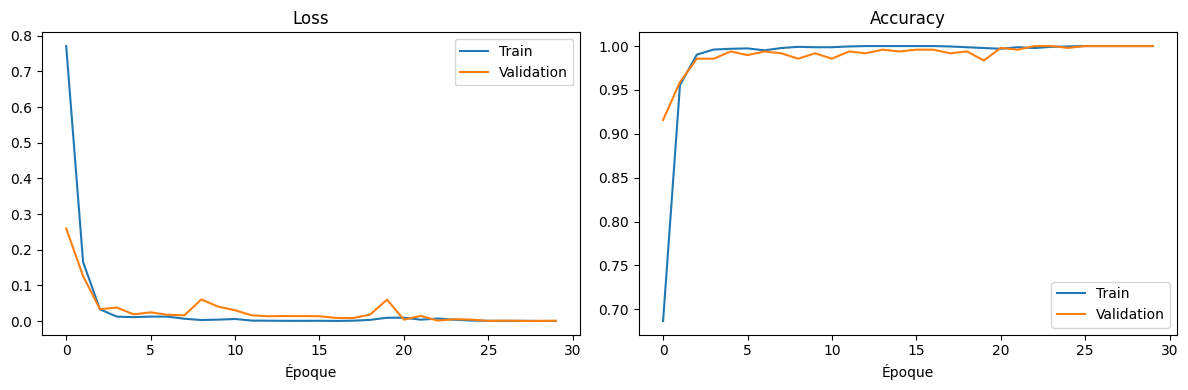

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"], label="Validation")
axes[0].set_title("Loss"); axes[0].set_xlabel("Époque"); axes[0].legend()

axes[1].plot(history["train_acc"], label="Train")
axes[1].plot(history["val_acc"], label="Validation")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Époque"); axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"))
plt.show()

### Evaluation finale sur le Test set

In [71]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        images = batch["image"].to(DEVICE)
        symptoms = batch["symptoms"].to(DEVICE)
        tabular = batch["tabular"].to(DEVICE)
        labels = batch["label"].to(DEVICE)

        logits = model(images, symptoms, tabular)
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
print(f" Accuracy Test: {acc:.4f}\n")
print(classification_report(all_labels, all_preds, target_names=CANONICAL_CLASSES))
print("Matrice de confusion:")
print(confusion_matrix(all_labels, all_preds))

 Accuracy Test: 0.9918

                        precision    recall  f1-score   support

               healthy       0.99      1.00      1.00       194
    lumpy_skin_disease       0.98      1.00      0.99       181
foot_and_mouth_disease       1.00      0.96      0.98       112

              accuracy                           0.99       487
             macro avg       0.99      0.99      0.99       487
          weighted avg       0.99      0.99      0.99       487

Matrice de confusion:
[[194   0   0]
 [  0 181   0]
 [  1   3 108]]


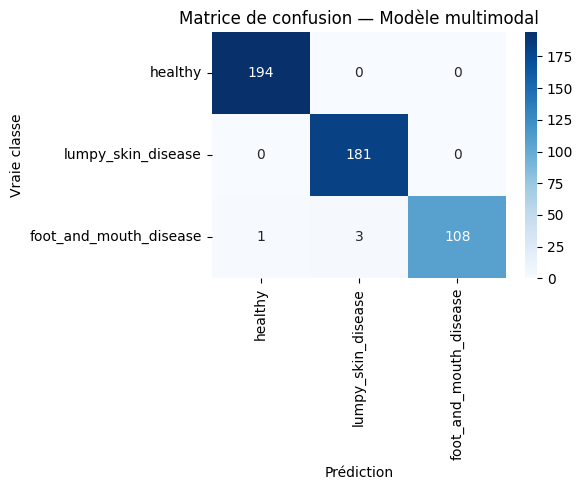

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CANONICAL_CLASSES, yticklabels=CANONICAL_CLASSES)
plt.xlabel("Prédiction")
plt.ylabel("Vraie classe")
plt.title("Matrice de confusion — Modèle multimodal")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=150)
plt.show()

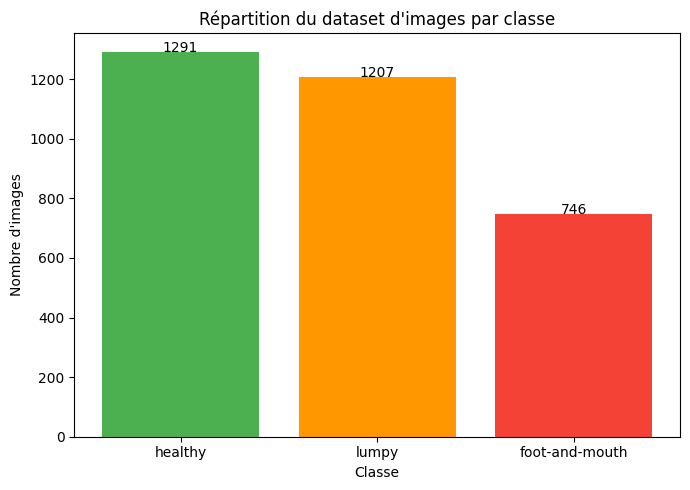

In [76]:
import matplotlib.pyplot as plt

counts = df_images["label"].value_counts()

plt.figure(figsize=(7, 5))
bars = plt.bar(counts.index, counts.values, color=["#4CAF50", "#FF9800", "#F44336"])
plt.title("Répartition du dataset d'images par classe")
plt.xlabel("Classe")
plt.ylabel("Nombre d'images")
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, str(int(height)), ha="center")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig1_distribution_images.png"), dpi=150)
plt.show()

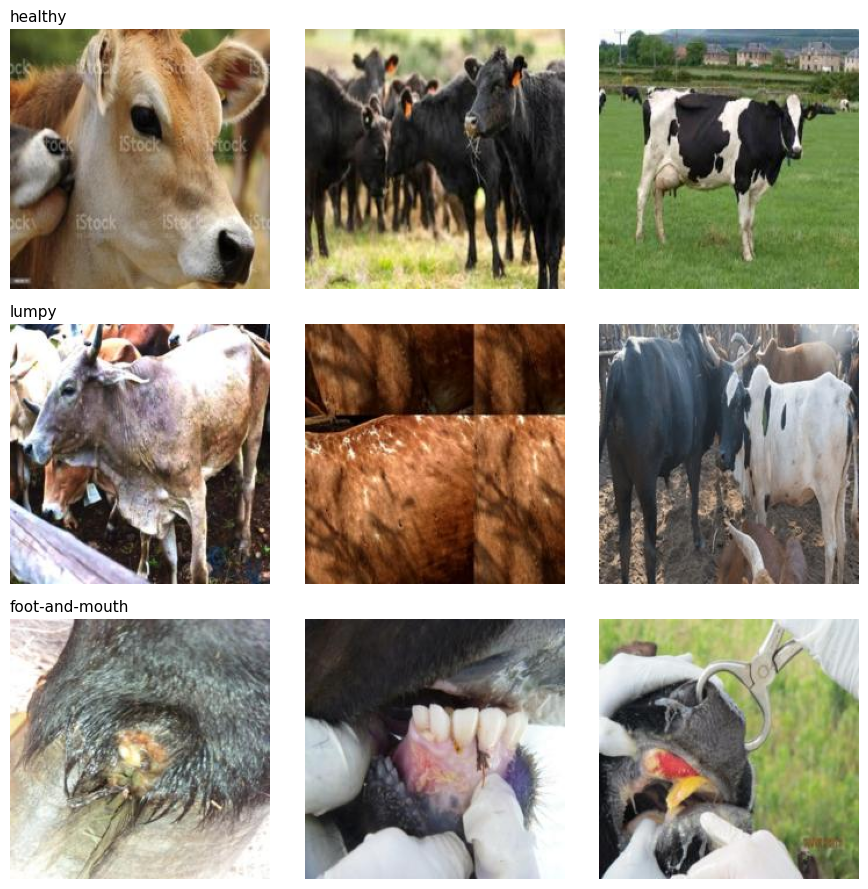

In [77]:
import random

fig, axes = plt.subplots(3, 3, figsize=(9, 9))
classes = df_images["label"].unique()

for row, cls in enumerate(classes):
    sample_paths = df_images[df_images["label"] == cls]["image_path"].sample(3, random_state=42).tolist()
    for col, path in enumerate(sample_paths):
        img = Image.open(path)
        axes[row, col].imshow(img)
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(cls, fontsize=10)
    axes[row, 0].set_title(cls, fontsize=11, loc="left")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig2_echantillon_images.png"), dpi=150)
plt.show()

In [78]:
print(f"Nombre total d'images : {len(df_images)}")
print(df_images['label'].value_counts())

Nombre total d'images : 3244
label
healthy           1291
lumpy             1207
foot-and-mouth     746
Name: count, dtype: int64


In [79]:
df_symptoms_clean = pd.read_csv(os.path.join(OUTPUT_DIR, "symptoms_clean.csv"))

for disease in df_symptoms_clean["disease"].unique():
    print(f"\n--- {disease} ---")
    sample = df_symptoms_clean[df_symptoms_clean["disease"] == disease].sample(2, random_state=42)
    for _, row in sample.iterrows():
        print("Brut    :", row["symptoms"])
        print("Nettoyé :", row["symptoms_clean"])
        


--- foot-and-mouth ---
Brut    : blisters, mouth ulcers
Nettoyé : blisters, mouth ulcers
Brut    : drooling, blisters, reduced milk production
Nettoyé : drooling, blisters, reduced milk production

--- healthy ---
Brut    : normal temperature, active, bright eyes, normal behavior
Nettoyé : normal temperature, active, bright eyes, normal behavior
Brut    : normal heart rate, normal behavior, good body condition, normal temperature
Nettoyé : normal heart rate, normal behavior, good body condition, normal temperature

--- lumpy ---
Brut    : eye discharge, reduced milk production, lameness, weight loss, fever
Nettoyé : eye discharge, reduced milk production, lameness, weight loss, fever
Brut    : eye discharge, depression, weight loss
Nettoyé : eye discharge, depression, weight loss


In [80]:
df_tabular_raw = pd.read_csv(TABULAR_CSV)  # avant encodage, pour compter les lignes/colonnes brutes
print(f"Nombre de lignes : {len(df_tabular_raw)}")
print(f"Nombre de variables (avant encodage) : {df_tabular_raw.shape[1]}")

target_encoder = joblib.load(os.path.join(ENCODERS_DIR, "tabular_target_encoder.pkl"))
print("Classes de Disease_Status :", list(target_encoder.classes_))

Nombre de lignes : 250000
Nombre de variables (avant encodage) : 40
Classes de Disease_Status : ['acidosis', 'anaplasmosis', 'anthrax', 'babesiosis', 'black_quarter', 'bloat', 'blue_tongue', 'bovine_respiratory_disease', 'bovine_tuberculosis', 'brucellosis', 'bvd_pestivirus', 'diarrhea', 'digestive_disorder', 'displaced_abomasum', 'dystocia', 'foot_and_mouth', 'foot_rot', 'grass_tetany', 'haemorrhagic_septicemia', 'hardware_disease', 'healthy', 'heat_stress', 'ibr_ipv', 'internal_parasites', 'johnes_disease', 'ketosis_clinical', 'ketosis_subclinical', 'lameness_clinical', 'laminitis', 'lumpy_skin_disease', 'malignant_catarrhal_fever', 'mange', 'mastitis_clinical', 'mastitis_subclinical', 'metritis', 'milk_fever', 'mineral_deficiency', 'ovarian_cysts', 'pink_eye', 'pneumonia', 'protein_deficiency', 'retained_placenta', 'ringworm', 'theileriosis', 'vitamin_deficiency']


In [1]:
df_images["label"].value_counts()

NameError: name 'df_images' is not defined